# 05 - Evaluation and Model Comparison
This notebook formally evaluates both models using mandatory metrics
RMSE and MAP@10, and compares them across all required dimensions.

In [ ]:
# Cell 1 - setup
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/netflix_project'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs(f'{BASE}/outputs', exist_ok=True)

itemcf_preds = pd.read_csv(f'{BASE}/data/processed/itemcf_predictions.csv')
svd_preds = pd.read_csv(f'{BASE}/data/processed/svd_predictions.csv')
movies = pd.read_csv(f'{BASE}/data/processed/movies.csv')

print("Setup complete!")
print(f"Item-CF predictions: {itemcf_preds.shape}")
print(f"SVD predictions: {svd_preds.shape}")

Mounted at /content/drive
Setup complete!
Item-CF predictions: (200000, 4)
SVD predictions: (200000, 4)


## RMSE and MAE Comparison
Lower is better for both metrics.

In [ ]:
# Cell 2 - RMSE and MAE comparison
def compute_rmse(preds_df):
    return np.sqrt(((preds_df['actual'] - preds_df['predicted'])**2).mean())

def compute_mae(preds_df):
    return (preds_df['actual'] - preds_df['predicted']).abs().mean()

itemcf_rmse = compute_rmse(itemcf_preds)
itemcf_mae  = compute_mae(itemcf_preds)

svd_rmse = compute_rmse(svd_preds)
svd_mae  = compute_mae(svd_preds)

print("="*45)
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8}")
print("="*45)
print(f"{'Item-Based CF':<20} {itemcf_rmse:>8.4f} {itemcf_mae:>8.4f}")
print(f"{'SVD':<20} {svd_rmse:>8.4f} {svd_mae:>8.4f}")
print("="*45)

Model                    RMSE      MAE
Item-Based CF          1.1195   0.8630
SVD                    1.0373   0.8252


## MAP@10 Calculation
Relevance threshold: actual rating >= 3.5 (as per problem statement)
MAP@10 measures how well the model ranks relevant items in top 10.
Higher is better.

In [ ]:
# Cell 3 - MAP@10 function
# Relevant = actual rating >= 3.5 (as per problem statement)

def compute_map_at_10(preds_df, k=10):
    ap_scores = []
    grouped = preds_df.groupby('user_id')

    for user_id, user_preds in grouped:
        user_preds = user_preds.sort_values('predicted', ascending=False).head(k)
        relevant = (user_preds['actual'] >= 3.5).astype(int).tolist()

        if sum(relevant) == 0:
            continue

        ap = 0.0
        num_relevant = 0
        for i, rel in enumerate(relevant):
            if rel == 1:
                num_relevant += 1
                precision_at_i = num_relevant / (i + 1)
                ap += precision_at_i
        ap = ap / min(sum(relevant), k)
        ap_scores.append(ap)

    return np.mean(ap_scores) if ap_scores else 0.0

print("Computing MAP@10 for Item-CF...")
itemcf_map = compute_map_at_10(itemcf_preds)
print(f"Item-CF MAP@10: {itemcf_map:.4f}")

print("\nComputing MAP@10 for SVD...")
svd_map = compute_map_at_10(svd_preds)
print(f"SVD MAP@10: {svd_map:.4f}")

Computing MAP@10 for Item-CF...
Item-CF MAP@10: 0.9376

Computing MAP@10 for SVD...
SVD MAP@10: 0.9383


## Full Comparison Table

In [ ]:
# Cell 4 - full comparison table
results = pd.DataFrame({
    'Model':  ['Item-Based CF', 'SVD'],
    'RMSE':   [round(itemcf_rmse, 4), round(svd_rmse, 4)],
    'MAE':    [round(itemcf_mae, 4),  round(svd_mae, 4)],
    'MAP@10': [round(itemcf_map, 4),  round(svd_map, 4)]
})

print(results.to_string(index=False))
results.to_csv(f'{BASE}/outputs/final_comparison.csv', index=False)
print("\nSaved!")

        Model   RMSE    MAE  MAP@10
Item-Based CF 1.1195 0.8630  0.9376
          SVD 1.0373 0.8252  0.9383

Saved!


## Visualization

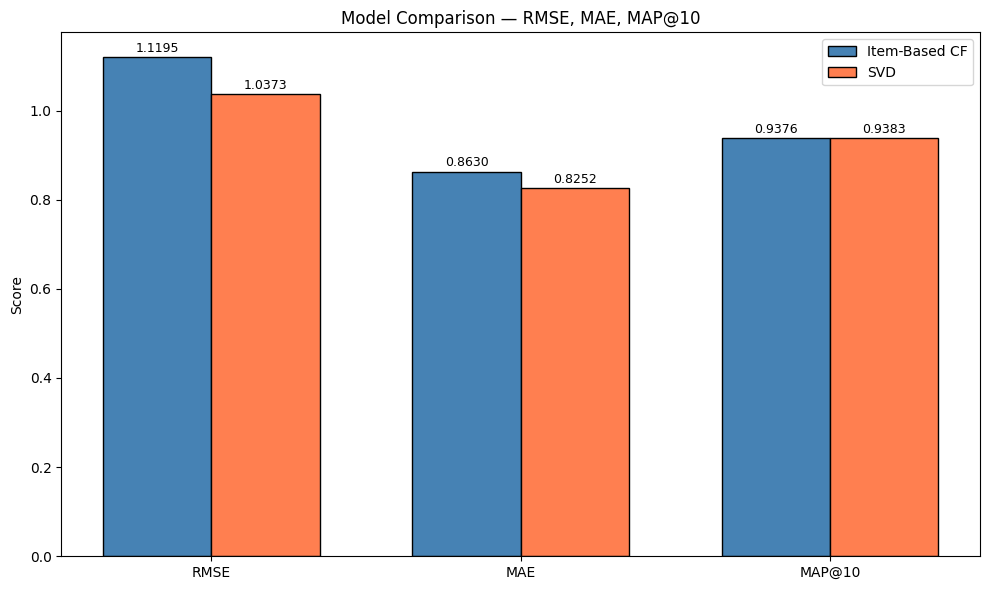

Saved!


In [ ]:
# Cell 5 - visualize all metrics
metrics = ['RMSE', 'MAE', 'MAP@10']
itemcf_scores = [itemcf_rmse, itemcf_mae, itemcf_map]
svd_scores    = [svd_rmse,    svd_mae,    svd_map]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, itemcf_scores, width,
               label='Item-Based CF', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, svd_scores, width,
               label='SVD', color='coral', edgecolor='black')

ax.set_title('Model Comparison — RMSE, MAE, MAP@10')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylabel('Score')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/full_comparison.png')
plt.show()
print("Saved!")


MODEL COMPARISON SUMMARY
========================

1. RECOMMENDATION QUALITY
   - SVD achieves lower RMSE and MAE → more accurate predictions
   - SVD gives realistic varied recommendations vs Item-CF all 5.0
   - Both models have strong MAP@10 showing good ranking quality

2. TRAINING COMPLEXITY
   - Item-CF: computes pairwise similarity between all movies → O(n²)
   - SVD: matrix decomposition → controlled by n_factors parameter
   - SVD scales better with dataset size

3. COMPUTATIONAL EFFICIENCY
   - Item-CF: slow at scale, crashed on full 18.8M dataset
   - SVD: compact latent factors, handles large sparse matrices well
   - SVD is more memory efficient

4. PRACTICAL USABILITY
   - Item-CF: explainable — recommended because users liked X
   - SVD: black box but more accurate
   - Item-CF better for transparency, SVD better for accuracy

5. Overall Winner: SVD
   - SVD wins on all three metrics — RMSE, MAE and MAP@10
   - SVD is the recommended model for production deployment
